## Polynomial Feature Engineering

In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import sys
from pathlib import Path
project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

In [82]:
import mlflow
mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
mlflow.set_registry_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")
experiment_name = "Production Time Prediction"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///D:/DEV/AIML/ProjectRepos/AzureML/templates/azureml/mlflow/artifacts', creation_time=1779115459900, experiment_id='1', last_update_time=1779115459900, lifecycle_stage='active', name='Production Time Prediction', tags={}, workspace='default'>

In [83]:
import pandas as pd

X_train = pd.read_parquet('../../data/split/production_time_train.parquet')
X_test = pd.read_parquet('../../data/split/production_time_test.parquet')

y_train = pd.read_parquet('../../data/split/production_time_train_target.parquet')['process_time']
y_test = pd.read_parquet('../../data/split/production_time_test_target.parquet')['process_time']

#### Load Preprocessor and Feature Creation Steps

In [84]:
import mlflow.sklearn

feature_creation_step = mlflow.sklearn.load_model("models:/feature_creation/latest")
preprocessor = mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")

#### GMM Clusterer and Feature Adder

In [85]:
from notebooks.utils.artifacts.gmm_clusterer import GMMClusterer, ClusterFeatureAdder


---

#### Correlation Pruning Step Definition
In the correlation pruning step, I will remove features that are highly correlated with each other to reduce multicollinearity. This should lower astronomical magnitude of condition number seen in previous notebooks to a more manageable level, improving model stability and performance.

In [86]:
# correlation_pruning.py
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np

class CorrPruning(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=None):
        if threshold is not None and (threshold <= 0 or threshold >= 1):
            raise ValueError("Threshold must be in the range (0, 1) or None.")
        self.threshold = threshold


    def fit(self, X, y=None):

        self.feature_names_ = (
            np.array(X.columns if hasattr(X, 'columns') 
            else [f"feature_{i}" for i in range(X.shape[1])])
        )
        
        uncorrelated_mask = self._get_uncorrelated_features_mask(X)

        self.selected_names_ = self.feature_names_[uncorrelated_mask]

        self.selected_idx_ = np.where(uncorrelated_mask)[0]

        return self


    def _get_uncorrelated_features_mask(self, X):
        X_arr = np.asarray(X)

        uncorrelated_mask = np.ones(X_arr.shape[1], dtype=bool)

        if self.threshold is None or self.threshold == 0 or self.threshold == 1:
            self.selected_names_ = self.feature_names_
            self.selected_idx_ = np.arange(X_arr.shape[1])
            return uncorrelated_mask

        with np.errstate(divide='ignore', invalid='ignore'):
            corr_matrix = np.abs(np.corrcoef(X_arr, rowvar=False))
        
        corr_matrix = np.nan_to_num(corr_matrix, nan=1.0)

        # upper_tri = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

        to_drop = set()

        for col_idx in range(corr_matrix.shape[1]):
            if col_idx in to_drop:
                continue  # already marked for dropping

            high_corr_indices = np.where(
                (corr_matrix[col_idx, :] > self.threshold) & 
                (np.arange(corr_matrix.shape[1]) > col_idx)
            )[0]
            
            for idx in high_corr_indices:
                to_drop.add(idx)

        uncorrelated_mask[list(to_drop)] = False

        return uncorrelated_mask


    def transform(self, X):
        check_is_fitted(self, "selected_idx_")
        X_filtered = np.asarray(X) if not isinstance(X, np.ndarray) else X
        return X_filtered[:, self.selected_idx_] # fast boolean masking


    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_names_")
        return self.selected_names_


Write script above to `notebooks/utils/artifacts/correlation_pruning.py`.

In [87]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path='../utils/artifacts/correlation_pruning.py'
)

#### SelectKBest Step Definition
In the SelectKBest step, I will select the top k features based on their correlation with the target variable. I will delegate the choice of k to Optuna, allowing it to find the optimal number of features to retain for the best model performance.

In [88]:
# kbest_features.py
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
import pandas as pd

class KBestPruning(BaseEstimator, TransformerMixin):
    def __init__(self, k=15):
        self.k = k

    def fit(self, X, y=None):
        self.feature_names_ = (
            np.array(X.columns if hasattr(X, 'columns') 
            else [f"feature_{i}" for i in range(X.shape[1])])
        )

        self.selector_ = SelectKBest(
            score_func=f_regression, 
            k=min(self.k, X.shape[1])
        )
        self.selector_.fit(X, y)
        
        # map selected features back to original polynomial space
        filtered_support = self.selector_.get_support()
        
        # store names of selected features
        self.selected_names_ = self.feature_names_[filtered_support]
        
        # compile mapping and indices of selected features
        self.selected_idx_ = np.where(filtered_support)[0]
        
        return self


    def transform(self, X):
        check_is_fitted(self, "selected_idx_")
        # X_selected = X.values if isinstance(X, pd.DataFrame) else X
        X_selected = np.asarray(X) # ensure we have a numpy array for indexing
        return X_selected[:, self.selected_idx_]


    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_names_")
        return self.selected_names_
    


Write script above to `notebooks/utils/artifacts/kbest_features.py`.

In [89]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path='../utils/artifacts/kbest_features.py'
)


---

#### Optuna Static Helper and Adaptive Budget Imports

In [ ]:
from notebooks.utils.utilities.optuna_study import OptunaStudy
from notebooks.utils.utilities.adaptive_budget import AdaptiveOptunaBudget

#### Run Optuna Trials for Polynomial Features

In [197]:
import optuna
from sklearn.linear_model import Ridge, Lasso, ElasticNet, QuantileRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

def get_regressor(trial, model_type, random_state=42):
    """ Helper function to create a regressor 
        based on the model type and trial hyperparameters."""
    
    if model_type == 'Ridge':
        return Ridge(
            alpha=trial.suggest_float('ridge_alpha', 1e-3, 100.0, log=True),
            random_state=random_state
        )
    elif model_type == 'Lasso':
        return Lasso(
            alpha=trial.suggest_float('lasso_alpha', 1e-4, 10.0, log=True),
            max_iter=50000,
            random_state=random_state
        )
    elif model_type == 'ElasticNet':
        return ElasticNet(
            max_iter=50000, 
            alpha=trial.suggest_float('elasticnet_alpha', 1e-4, 10.0, log=True), 
            l1_ratio=trial.suggest_float('elasticnet_l1_ratio', 0.01, 0.99),
            random_state=random_state
        )
    elif model_type == 'QuantileRegressor':
        return QuantileRegressor(
            alpha=trial.suggest_float('quantile_alpha', 1e-4, 10.0, log=True),
            quantile=trial.suggest_categorical('quantile', [0.9]),
            # max_iter=50000,
            solver='highs'
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from notebooks.utils.utilities.optuna_study import OptunaStudy
optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_pipeline(trial, cfg):
    """ Optuna objective function to optimize the regression pipeline 
        with optional GMM clustering, polynomial features, and correlation features."""
    
    (
        model_type, 
        use_clusterer, 
        use_poly, 
        use_corr, 
        variance_penalty
    ) = cfg

    steps = [
        ('feature_creation', feature_creation_step),
        ('preprocess', preprocessor)
    ]

    if use_clusterer:
        steps.append(('cluster_feat', ClusterFeatureAdder(
            GMMClusterer(
                n_components=trial.suggest_int('n_clusters', 2, 6),
                random_state=42,
                max_iter=5000,
                reg_covar=1e-3,  # regularization to prevent singular covariance matrices
                soft_clusters=trial.suggest_categorical('soft_clusters', [True, False])
            ),
            ohe=OneHotEncoder(
                sparse_output=False, 
                handle_unknown='ignore', 
                drop='first'
            )
        )))

    if use_poly:
        steps.append(('poly_select', PolynomialFeatures(
            degree=trial.suggest_categorical('degree', [2]), 
            interaction_only=False, 
            include_bias=False
        )))

    if use_corr:
        steps.append(('corr_prune', CorrPruning(
            threshold=trial.suggest_float('corr_threshold', 0.7, 0.95)
        )))

    if use_poly:
        steps.append(('kbest_select', KBestPruning(
            k=trial.suggest_int('k_best_features', 10, 60)
        )))

    steps.append(('scaler', StandardScaler()))

    steps.append(('regressor', get_regressor(trial, model_type)))
 
    # build pipeline
    eval = Pipeline(steps=steps)

    return OptunaStudy.cross_validate(
        trial, 
        eval, 
        X_train, y_train,
        variance_penalty=variance_penalty
    )

In [253]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_adaptive(        
        trial, 
        budget,
        models: list[str],
        use_clusterer_opts=[True], #, False],
        use_poly_opts=[True], #, False],
        use_corr_opts=[True], #, False],
        use_kbest_opts=[True],
        variance_penalty_opts=[False],
        ):

    trial.suggest_categorical('use_kbest', use_kbest_opts)
    
    cfg = (
        trial.suggest_categorical('model_type', models),
        trial.suggest_categorical('use_clusterer', use_clusterer_opts),
        trial.suggest_categorical('use_poly', use_poly_opts),
        trial.suggest_categorical('use_corr', use_corr_opts),
        trial.suggest_categorical('variance_penalty', variance_penalty_opts)
    )

    # Check if we should stop early based on the adaptive budget
    if budget.should_stop(cfg):
        raise optuna.TrialPruned()

    score = run_pipeline(trial, cfg)

    budget.update(cfg, score)

    return score

In [254]:
def get_run_title_(cfg):
    def if_valid(feature_name):
        return hasattr(cfg, feature_name) and getattr(cfg, feature_name)
    cfg_string = f"{cfg.model}"
    cfg_string += " | Clusterer" if if_valid('use_clusterer') else ""
    cfg_string += " | Poly" if if_valid('use_poly') else ""
    cfg_string += " | CorrPrune" if if_valid('use_corr') else ""
    cfg_string += " | KBest" if if_valid('use_kbest') else ""
    cfg_string += " | VarPenalty" if if_valid('var_penalty') else ""

    return f"AdaptiveOpt_{cfg_string}"

In [ ]:
from optuna.pruners import MedianPruner

def run_experiments(configs, global_budget=200, adaptive_budget_params=None):
    results = []

    for cfg in configs:
        print(f"Optimizing {get_run_title_(cfg)}...")

        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
        
        budget = AdaptiveOptunaBudget(
            base_trials=20,
            patience=25,
            min_improve=1e-3,
            ascending=False,
            **(adaptive_budget_params or {})
        )

        study.optimize(
            lambda trial: objective_adaptive(
                trial, 
                budget=budget,
                models=[cfg.model],
                variance_penalty_opts=[cfg.var_penalty]
            ),
            n_trials=global_budget,
            n_jobs=1
        )

        converged = budget.no_improve[cfg] < budget.patience
        results.append((cfg, study, converged))
    
    return results


def aggregate_results(results):
    trails_list = []
    for cfg, study, converged in results:
        use_clusterer = study.best_trial.params.get('use_clusterer', False)
        use_poly = study.best_trial.params.get('use_poly', False)
        use_corr = study.best_trial.params.get('use_corr', False)
        use_kbest = study.best_trial.params.get('use_kbest', False)
        use_var_penalty = cfg.var_penalty
        
        study_name = (
            f"{cfg.model.lower()}"
            + f"{'_vp' if use_var_penalty else ''}"
            + f"{'_c' if use_clusterer else ''}"
            + f"{'_p' if use_poly else ''}"
            + f"{'_cr' if use_corr else ''}"
            + f"{'_kb' if use_kbest else ''}"
        )

        trails_list.append({
            'study': study,
            'study_name': study_name,
            
            'Model': study.best_trial.params.get('model_type'),
            'Optuna Score': study.best_value,

            # settings
            'Use Clusterer': '✔' if study.best_trial.params.get('use_clusterer', False) else '',
            'Use Poly': '✔' if study.best_trial.params.get('use_poly', False) else '',
            'Use Corr': '✔' if study.best_trial.params.get('use_corr', False) else '',
            'Use KBest': '✔' if study.best_trial.params.get('use_kbest', False) else '',
            'Variance Penalty': '✔' if cfg.var_penalty else '',

            # main regression metrics
            'RMSE': study.best_trial.user_attrs.get("RMSE", None),
            'MAE': study.best_trial.user_attrs.get("MAE", None),
            'R2': study.best_trial.user_attrs.get("R2", None),
            'RMSE Std': study.best_trial.user_attrs.get("RMSE_std", None),

            # quantile regression metrics
            'pinball_loss': study.best_trial.user_attrs.get("pinball_loss", None),
            'coverage': study.best_trial.user_attrs.get("coverage", None),
            'coverage_error': study.best_trial.user_attrs.get("coverage_error", None),
            
            # stability and convergence indicators
            'Condition Number': study.best_trial.user_attrs.get("condition_number", None),
            'Converged': '✔' if converged else '✘',

            'Best': '',

            # additional info for analysis
            'base_model': study.best_trial.params.get('model_type').lower(),
            'best_params': study.best_params,
            'fold_scores': {
                'RMSE': study.best_trial.user_attrs['fold_RMSE'],
                'MAE': study.best_trial.user_attrs['fold_MAE'],
                'R2': study.best_trial.user_attrs['fold_R2']
            },
        })
    
    return trails_list

Utilities for Optuna optimization

In [257]:
def mark_best_models(df, score_col='Optuna Score', group_col='Model', ascending=True):
    """ Marks the best model per group based on the specified score column."""
    for model in df[group_col].unique():
        if ascending:
            best_idx = df[df[group_col] == model][score_col].idxmin()
        else:
            best_idx = df[df[group_col] == model][score_col].idxmax()
        df.loc[best_idx, 'Best'] = '✔'

In [258]:
from IPython.display import display, Markdown

def display_optuna_results(
        scores_list,
        sort_by='Optuna Score',
        subset_cols=['Model', 'Use Clusterer', 'Use Poly'],

        best_in_group='Optuna Score',
        group_by='Model',
        best_ascending=True,

        std_metrics=True, 
        quantile_metrics=False,
        additional_metrics_cols=[]
        ):
    
    display_columns = subset_cols + ['Optuna Score'] + (
        ['RMSE', 'MAE', 'R2'] if std_metrics else []
    ) + additional_metrics_cols + (
        ['pinball_loss', 'coverage', 'coverage_error'] if quantile_metrics else []
    ) + ['Best']

    df = (pd.DataFrame(scores_list, columns=display_columns)
        .sort_values(sort_by)
        .drop_duplicates(subset=subset_cols, keep='first')
        .fillna('')
        .reset_index(drop=True))

    mark_best_models(
        df, 
        score_col=best_in_group, 
        group_col=group_by, 
        ascending=best_ascending)

    display(df)
    display(Markdown(
        f"**Note:** Best '{best_in_group}' per '{group_by}' "
        f"are marked with ✔ in the 'Best' column."))

In [259]:
from dataclasses import dataclass
from itertools import product

@dataclass(frozen=True)
class ExperimentConfig:
    model: str
    var_penalty: bool


cfg_poly = [
    ExperimentConfig(
        model=model, 
        var_penalty=var_penalty
        )
    for model, var_penalty in product(
    # for var_penalty in product(
        # ['Ridge', 'Lasso', 'ElasticNet'], 
        ['ElasticNet'],
        [True, False]  # var_penalty
    )
]

#### Run Experiments

In [273]:
opt_results_lin = run_experiments(cfg_poly, global_budget=1000, adaptive_budget_params={
    'base_trials': 30,
    'patience': 35,
    'min_improve': 1e-3,
    'ascending': False
})

Optimizing AdaptiveOpt_ElasticNet | VarPenalty...
Optimizing AdaptiveOpt_ElasticNet...


#### Aggregate Results

In [274]:
trails_list = aggregate_results(opt_results_lin)

In [280]:
display_optuna_results(
    trails_list,
    sort_by='RMSE', 
    best_in_group='RMSE',
    subset_cols=['Model', 'Use Clusterer', 'Use Poly', 'Use Corr', 'Use KBest', 'Variance Penalty'],
    additional_metrics_cols=['RMSE Std', 'Condition Number']
)

,Model,Use Clusterer,Use Poly,Use Corr,Use KBest,Variance Penalty,Optuna Score,RMSE,MAE,R2,RMSE Std,Condition Number,Best
0,ElasticNet,✔,✔,✔,✔,,38.24320,38.229214,18.424673,0.845787,13.599417,24.035599,✔
1,ElasticNet,✔,✔,✔,✔,✔,51.63439,38.511944,18.262874,0.844539,13.108561,23.460214,


**Note:** Best 'RMSE' per 'Model' are marked with ✔ in the 'Best' column.

In [281]:
for trail in trails_list:
    study_name = trail.get('study_name')
    print(f"Displaying results for {study_name}")
    OptunaStudy.display_optuna_results(
        mlflow, 
        trail.get('study'), 
        f"optuna_linear_models_{study_name}")

Displaying results for elasticnet_vp_c_p_cr_kb


> ### optuna_linear_models_elasticnet_vp_c_p_cr_kb

##### Run: `optuna_linear_models_elasticnet_vp_c_p_cr_kb`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,38.5119,26.8505,54.4477,54.6499,27.8212,28.7904
MAE,18.2629,16.3247,20.2473,20.2812,16.5750,17.8862
R2,0.8445,0.9028,0.7798,0.7063,0.9027,0.9311


### Best Hyperparameters:

,value
use_kbest,True
model_type,ElasticNet
use_clusterer,True
use_poly,True
use_corr,True
variance_penalty,True
n_clusters,3
soft_clusters,True
degree,2
corr_threshold,0.766301


Displaying results for elasticnet_c_p_cr_kb


> ### optuna_linear_models_elasticnet_c_p_cr_kb

##### Run: `optuna_linear_models_elasticnet_c_p_cr_kb`, Trials: 1000

,mean_scores,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
RMSE,38.2292,25.0537,54.4141,55.2288,28.3073,28.1422
MAE,18.4247,15.9475,20.6003,20.6254,17.3406,17.6096
R2,0.8458,0.9153,0.7801,0.7001,0.8993,0.9341


### Best Hyperparameters:

,value
use_kbest,True
model_type,ElasticNet
use_clusterer,True
use_poly,True
use_corr,True
variance_penalty,False
n_clusters,4
soft_clusters,True
degree,2
corr_threshold,0.764859


In [282]:
df_top = (pd.DataFrame(trails_list)
    .sort_values('RMSE')
    .drop_duplicates(subset=['base_model', 'Variance Penalty'], keep='first')
    .reset_index(drop=True)
    .drop(columns='base_model'))

final_df_ = pd.concat([
    df_top.drop(columns=['best_params', 'fold_scores', 'study']), 
    pd.DataFrame(
        df_top['best_params'].tolist(), 
        index=df_top.index
    )
], axis=1)

display(final_df_
    .round(4)
    .fillna('')
    .drop(columns=['Model'])
    .set_index('model_type')
    .rename_axis('Model')
    .T
)

Model,ElasticNet,ElasticNet
study_name,elasticnet_c_p_cr_kb,elasticnet_vp_c_p_cr_kb
Optuna Score,38.2432,51.6344
Use Clusterer,✔,✔
Use Poly,✔,✔
Use Corr,✔,✔
Use KBest,✔,✔
Variance Penalty,,✔
RMSE,38.2292,38.5119
MAE,18.4247,18.2629
R2,0.8458,0.8445



---
Build pipelines from experiment configurations and run Optuna trials for each configuration.

In [294]:
from sklearn.preprocessing import PolynomialFeatures

def get_pipeline_from_study(study):
    selected_model = study['Model'].lower()
    best_params = study['best_params']

    use_poly = best_params['use_poly']
    use_corr = best_params['use_corr']
    use_kbest = best_params['use_kbest']
    model = best_params['model_type']

    print(  f"Building final pipeline for {model} "
            f"{'with' if use_poly else 'without'} polynomial features, "
            f"{'with' if use_corr else 'without'} correlation pruning, "
            f"{'with' if use_kbest else 'without'} KBest feature selection.")

    return Pipeline([
        ('feature_creation', feature_creation_step),
        ('preprocess', preprocessor),
        ('cluster_feat', ClusterFeatureAdder(
            GMMClusterer(
                    n_components=best_params['n_clusters'],
                    random_state=42,
                    max_iter=5000,
                    reg_covar=1e-3,
                    soft_clusters=best_params['soft_clusters']
                ),
                ohe=OneHotEncoder(
                    sparse_output=False, 
                    handle_unknown='ignore', 
                    drop='first'
                )

            ) if best_params['use_clusterer'] else "passthrough"),

        ('poly_select', PolynomialFeatures(
            degree=2, interaction_only=False, include_bias=False) 
            if use_poly else "passthrough" ),

        ('corr_prune', CorrPruning(
                threshold=best_params['corr_threshold']
            ) if use_corr else "passthrough"),

        ('kbest_select', KBestPruning(
            k=best_params['k_best_features']) 
            if use_kbest else "passthrough"),

        ('scaler', StandardScaler()),

        ('regressor', Ridge(
                alpha=best_params['ridge_alpha']
            ) if model == 'Ridge' else ElasticNet(
                alpha=best_params['elasticnet_alpha'],
                l1_ratio=best_params['elasticnet_l1_ratio'],
                max_iter=50000,
                tol=1e-3
            ) if model == 'ElasticNet' else Lasso(
                alpha=best_params['lasso_alpha'],
                max_iter=50000,
                tol=1e-3
            ) if model == 'Lasso' else QuantileRegressor(
                alpha=best_params['quantile_alpha'],
                quantile=best_params['quantile'],
                solver='highs'
            )
        )
    ])

final_pipelines = {}
for _, row in df_top.iterrows():
    pipeline_key = row['study_name']
    final_pipelines[pipeline_key] = get_pipeline_from_study(row)
    final_pipelines[pipeline_key].set_output(transform="pandas")
    final_pipelines[pipeline_key].fit(X_train, y_train)

Building final pipeline for ElasticNet with polynomial features, with correlation pruning, with KBest feature selection.
Building final pipeline for ElasticNet with polynomial features, with correlation pruning, with KBest feature selection.


In [295]:
for model_name, pipeline in final_pipelines.items():
    display(Markdown(f"### Final Pipeline for `{model_name.lower()}`"))
    display(pipeline)

### Final Pipeline for `elasticnet_c_p_cr_kb`

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa

### Final Pipeline for `elasticnet_vp_c_p_cr_kb`

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_creation', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,density_steel,7850
,mat_allowance,600
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defa


---
#### GMM Cluster Features Analysis

### Cluster Feature Profiles for `elasticnet_c_p_cr_kb`

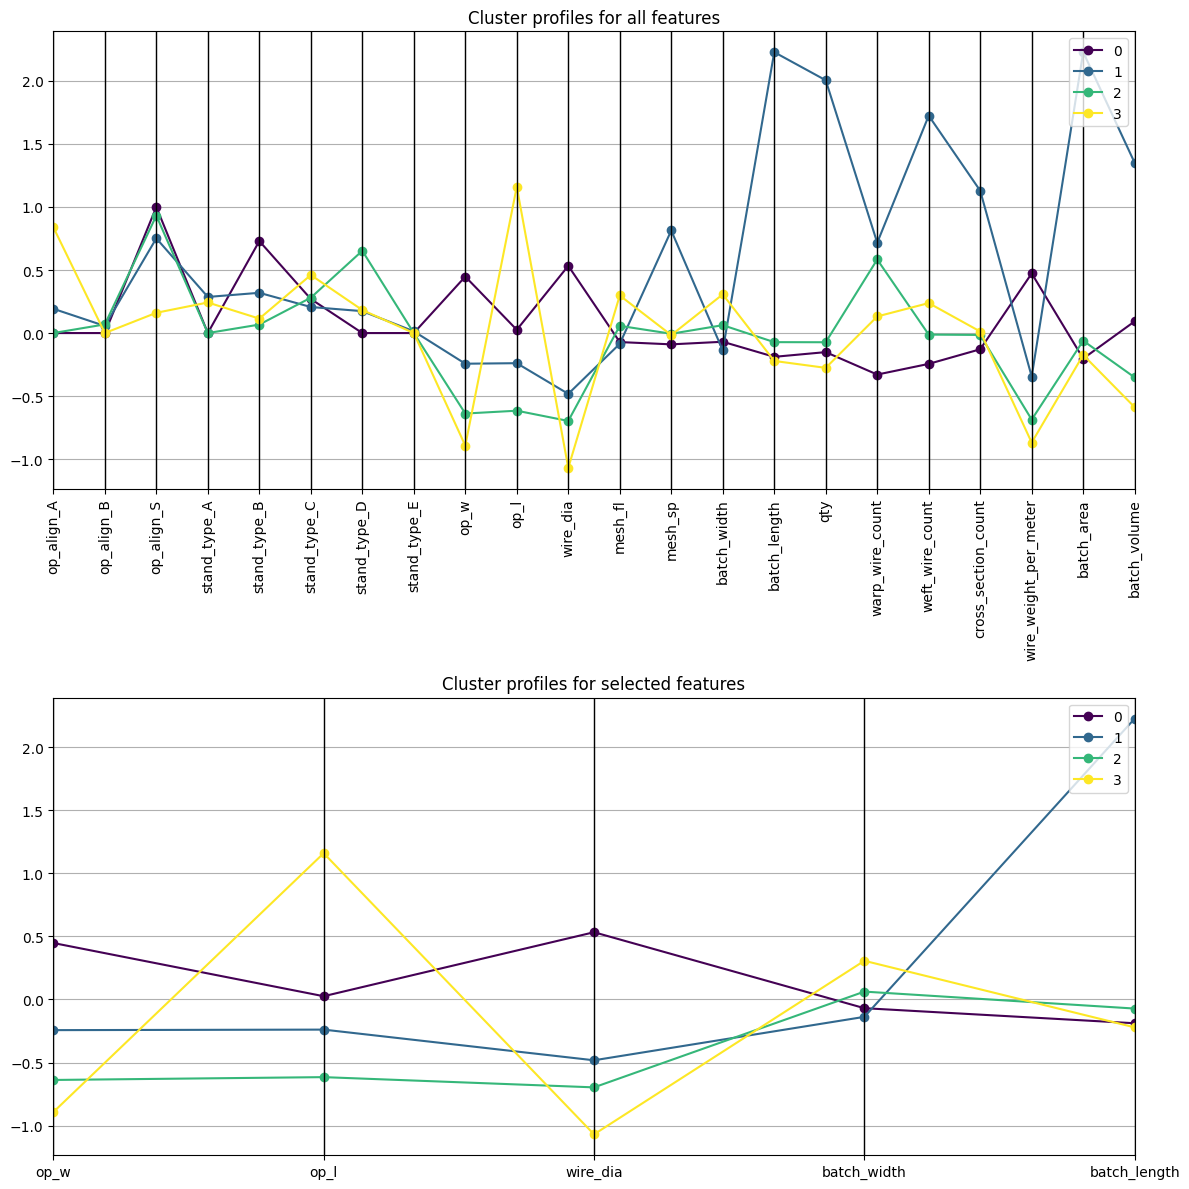

### Cluster Feature Profiles for `elasticnet_vp_c_p_cr_kb`

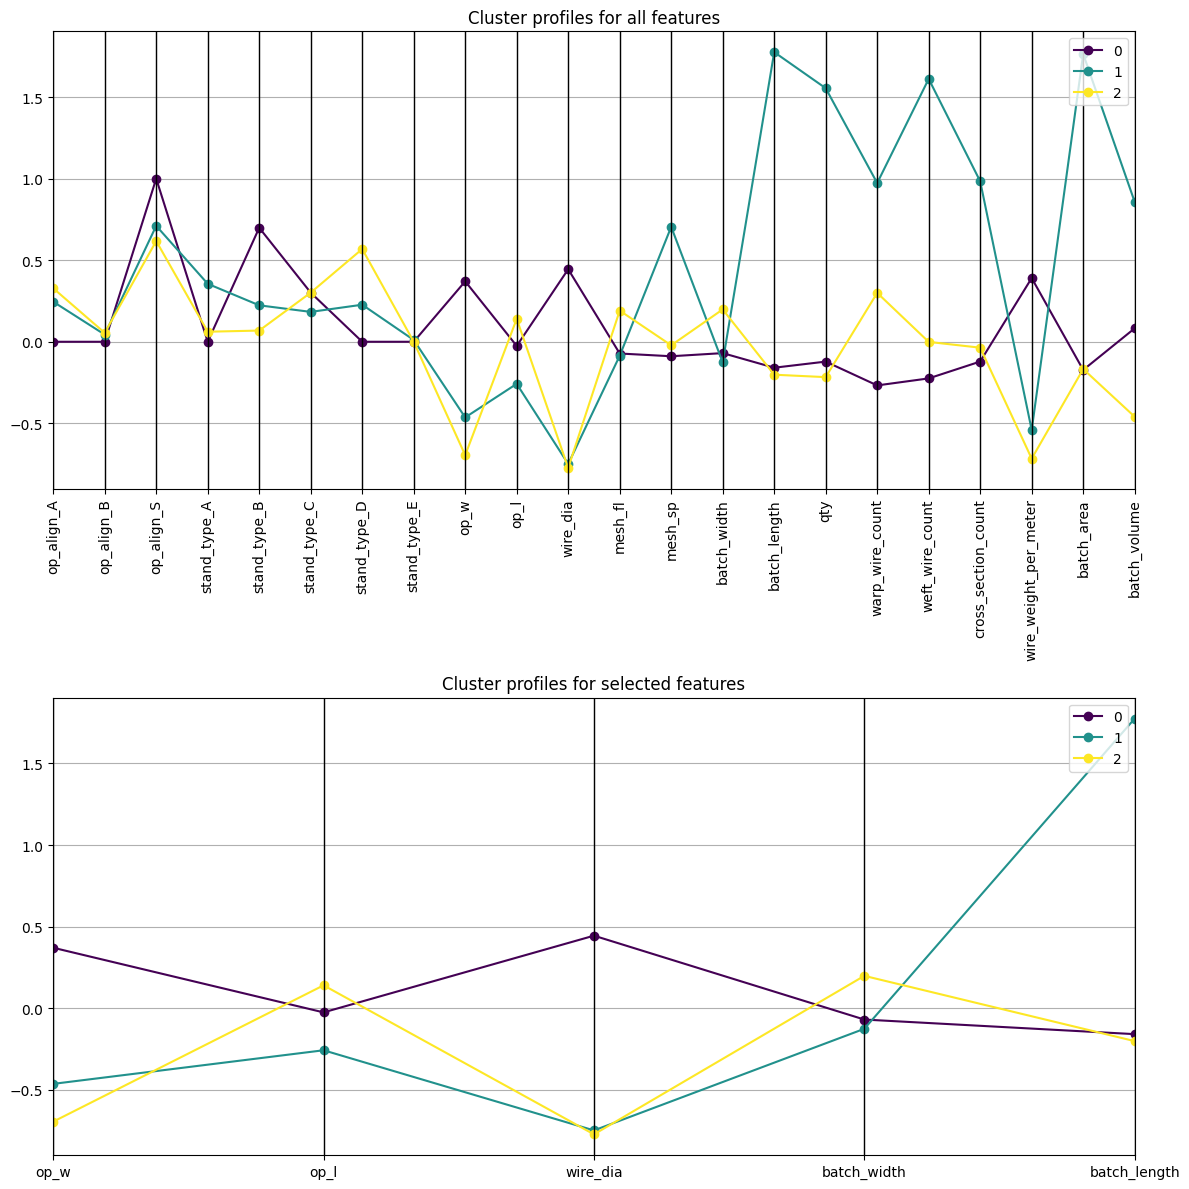

In [299]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

for model_name, final_pipeline in final_pipelines.items():
    if not any(isinstance(step, ClusterFeatureAdder) for name, step in final_pipeline.named_steps.items()):
        print(f"Selected {model_name} does not use cluster features.")
        print("No cluster features were added, skipping parallel coordinates plot.")
    else:
        display(Markdown(f"### Cluster Feature Profiles for `{model_name.lower()}`"))
        
        features_all = final_pipeline.named_steps['cluster_feat'].get_feature_names_out()
        features = [f for f in features_all if not f.startswith('cluster_')]  # tylko oryginalne cechy, bez tych z klastrami

        # for easier differentiation use smaller set
        feat_disp = ['op_w', 'op_l', 'wire_dia', 'batch_width', 'batch_length']

        X_parallel = final_pipeline.named_steps['cluster_feat'].transform(
            final_pipeline.named_steps['preprocess'].transform(
                final_pipeline.named_steps['feature_creation'].transform(
                    X_train
                )
            )
        )

        cluster_means = pd.DataFrame(
            X_parallel, 
            columns=final_pipeline.named_steps['cluster_feat'].get_feature_names_out()
        )

        cluster_means['cluster_id'] = np.argmax(cluster_means.filter(like='cluster_').values, axis=1)
        cluster_means = cluster_means.groupby('cluster_id')[features].mean().reset_index()

        plt.figure(figsize=(12, 12))

        # =====================================
        # Parallel coordinates plot (all features)
        # =====================================
        plt.subplot(2, 1, 1)
        parallel_coordinates(cluster_means, 'cluster_id', colormap='viridis', marker='o')
        plt.title('Cluster profiles for all features')
        plt.xticks(rotation=90)

        # =====================================
        # Parallel coordinates plot (selected features)
        # =====================================
        plt.subplot(2, 1, 2)
        parallel_coordinates(cluster_means[['cluster_id'] + feat_disp], 'cluster_id', colormap='viridis', marker='o')
        plt.title('Cluster profiles for selected features')

        # Final layout adjustments
        plt.tight_layout()
        plt.show()


#### Feature Importance Analysis

### Feature Importance for `elasticnet_c_p_cr_kb`

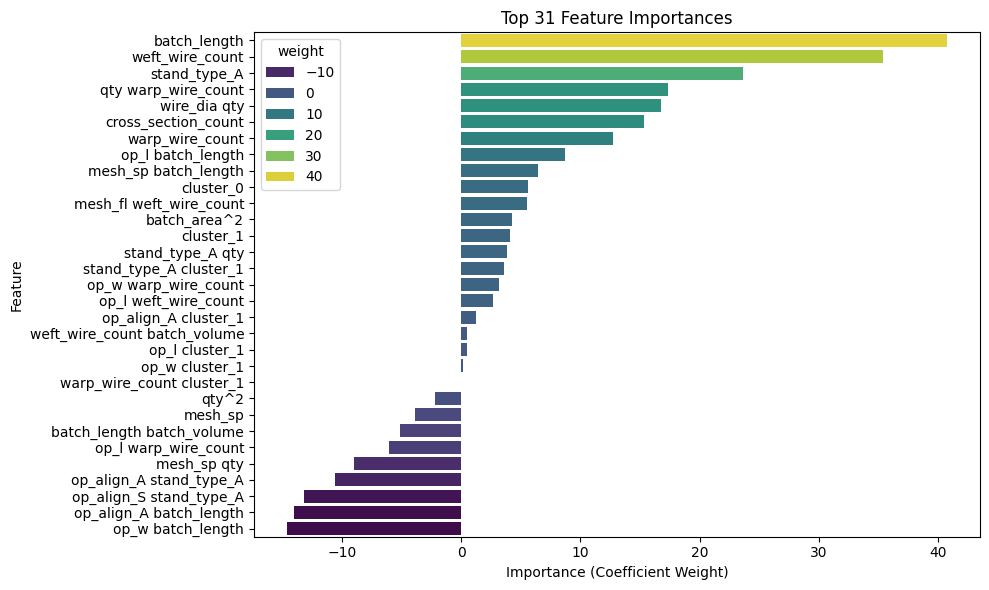

### Feature Importance for `elasticnet_vp_c_p_cr_kb`

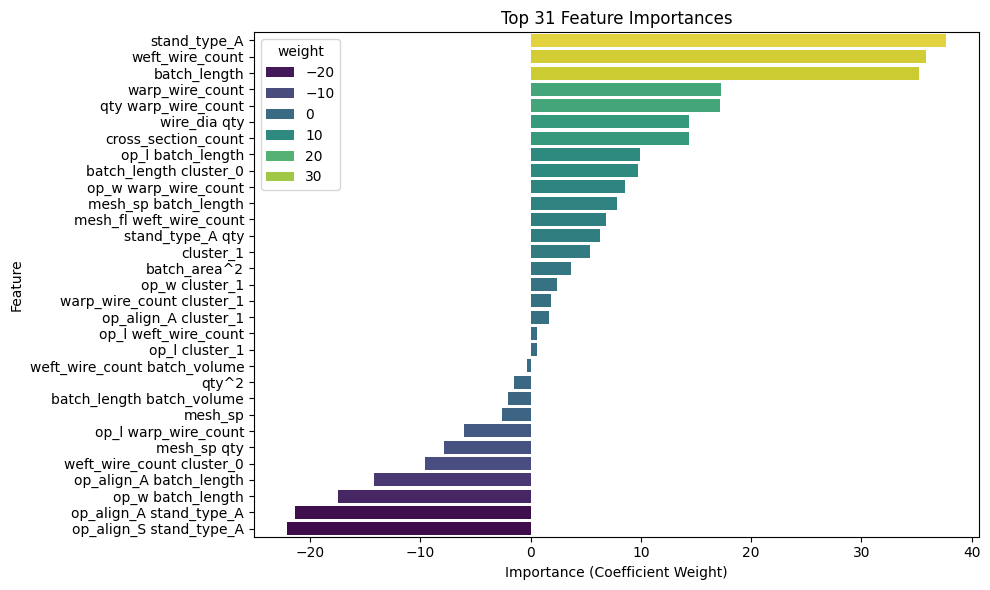

In [301]:
import pandas as pd
from notebooks.utils.utilities.plot_utils import plot_feature_importance

for model_name, final_pipeline in final_pipelines.items():
    display(Markdown(f"### Feature Importance for `{model_name.lower()}`"))

    feature_names = final_pipeline[:-1].get_feature_names_out()

    weights = final_pipeline[-1].coef_ if hasattr(final_pipeline[-1], 'coef_') else (
        final_pipeline[-1].feature_importances_ if hasattr(final_pipeline[-1], 'feature_importances_') else None
    )

    importance_df = (
        pd.DataFrame({'feature': feature_names, 'weight': weights})
        .sort_values(by='weight', ascending=False)
        .reset_index(drop=True)
    )

    plot_feature_importance(importance_df, top_n=len(importance_df))


#### Collinearity Analysis

### Correlation Matrix for `elasticnet_c_p_cr_kb`

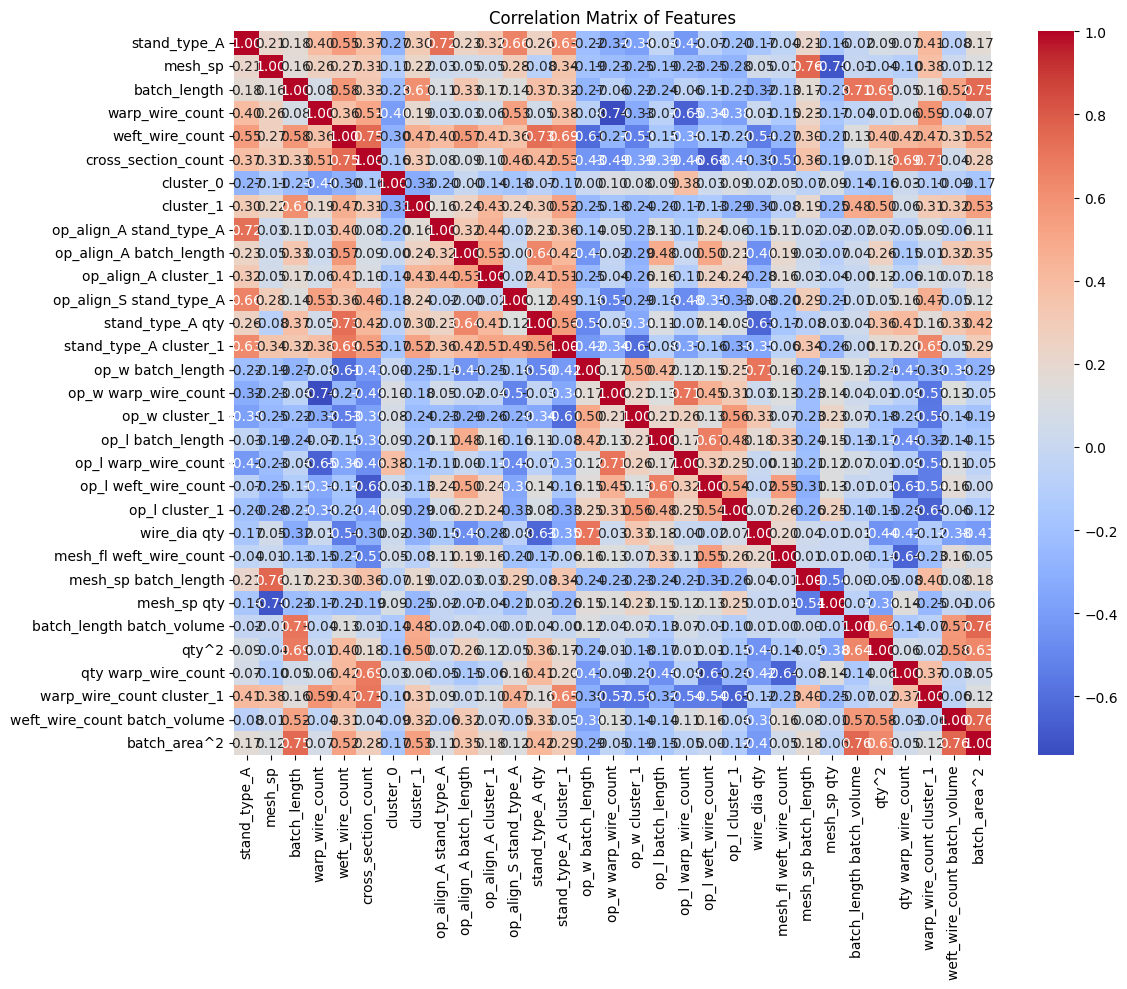

### Correlation Matrix for `elasticnet_vp_c_p_cr_kb`

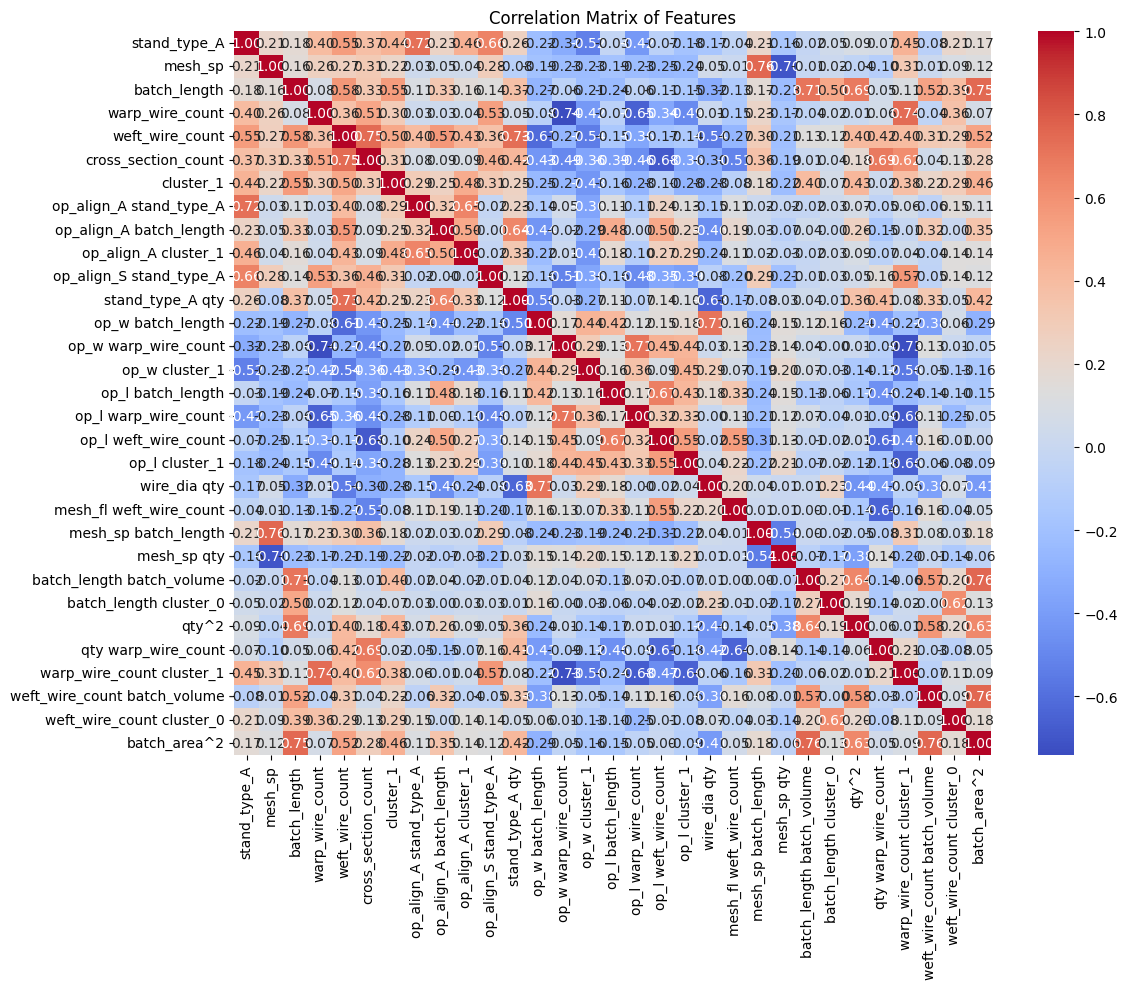

In [303]:
from notebooks.utils.utilities.plot_utils import plot_correlation_matrix

for model_name, final_pipeline in final_pipelines.items():
    display(Markdown(f"### Correlation Matrix for `{model_name.lower()}`"))
    plot_correlation_matrix(final_pipeline, X_train)

---

#### Log Pipelines to MLflow

In [309]:
# trails_list
for trail in trails_list:
    study_name = trail.get('study_name')
    print(f"Displaying results for {study_name}")
    rmse = trail.get('study').best_trial.user_attrs.get("RMSE", None)
    mae = trail.get('study').best_trial.user_attrs.get("MAE", None)
    r2 = trail.get('study').best_trial.user_attrs.get("R2", None)
    params = trail.get('best_params')
    print(f"Best RMSE for {study_name}: {rmse}")
    print(f"Best MAE for {study_name}: {mae}")
    print(f"Best R2 for {study_name}: {r2}")
    print(f"Best Hyperparameters for {study_name}: {params}")

Displaying results for elasticnet_vp_c_p_cr_kb
Best RMSE for elasticnet_vp_c_p_cr_kb: 38.51194438838139
Best MAE for elasticnet_vp_c_p_cr_kb: 18.26287380502779
Best R2 for elasticnet_vp_c_p_cr_kb: 0.8445390063413368
Best Hyperparameters for elasticnet_vp_c_p_cr_kb: {'use_kbest': True, 'model_type': 'ElasticNet', 'use_clusterer': True, 'use_poly': True, 'use_corr': True, 'variance_penalty': True, 'n_clusters': 3, 'soft_clusters': True, 'degree': 2, 'corr_threshold': 0.7663008740351042, 'k_best_features': 31, 'elasticnet_alpha': 0.0003977053879014088, 'elasticnet_l1_ratio': 0.1867207635811429}
Displaying results for elasticnet_c_p_cr_kb
Best RMSE for elasticnet_c_p_cr_kb: 38.22921423696746
Best MAE for elasticnet_c_p_cr_kb: 18.424672613041054
Best R2 for elasticnet_c_p_cr_kb: 0.8457865352386211
Best Hyperparameters for elasticnet_c_p_cr_kb: {'use_kbest': True, 'model_type': 'ElasticNet', 'use_clusterer': True, 'use_poly': True, 'use_corr': True, 'variance_penalty': False, 'n_clusters': 4

In [310]:
import mlflow.sklearn

# ========================================
# Best Linear Model Results Logging
# ========================================
for trail in trails_list:
    with mlflow.start_run(run_name=f"linear_model_poly_{trail.get('study_name')}") as run:
        print(f"Logging parameters and metrics of the best linear model for {trail.get('study_name')}...")
        study_name = trail.get('study_name')
        print(f"Displaying results for {study_name}")
        rmse = trail.get('study').best_trial.user_attrs.get("RMSE", None)
        mae = trail.get('study').best_trial.user_attrs.get("MAE", None)
        r2 = trail.get('study').best_trial.user_attrs.get("R2", None)
        params = trail.get('best_params')
        mlflow.log_params(params)
        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("r2", float(r2))
    print(f"Best linear model parameters and metrics for {study_name} logged to MLflow.")

# ========================================
# Log pipelines to MLflow
# ========================================
with mlflow.start_run(run_name="final_pipelines"):
    # register pipelines as MLflow models
    for model_name, final_pipeline in final_pipelines.items():
        mlflow.sklearn.log_model(
            final_pipeline,
            name=f"{model_name.lower()}_pipeline",
            registered_model_name=f"{model_name.lower()}_pipeline",
            pyfunc_predict_fn="predict"
        )
        print(f"""
        To load the {model_name.lower()} pipeline later:
        {model_name.lower()}_pipeline = mlflow.sklearn.load_model("models:/{model_name.lower()}_pipeline/latest")
        """)

2026/05/22 04:31:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging parameters and metrics of the best linear model for elasticnet_vp_c_p_cr_kb...
Displaying results for elasticnet_vp_c_p_cr_kb
Best linear model parameters and metrics for elasticnet_vp_c_p_cr_kb logged to MLflow.
Logging parameters and metrics of the best linear model for elasticnet_c_p_cr_kb...
Displaying results for elasticnet_c_p_cr_kb
Best linear model parameters and metrics for elasticnet_c_p_cr_kb logged to MLflow.


Registered model 'elasticnet_c_p_cr_kb_pipeline' already exists. Creating a new version of this model...
Created version '2' of model 'elasticnet_c_p_cr_kb_pipeline'.
2026/05/22 04:32:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



        To load the elasticnet_c_p_cr_kb pipeline later:
        elasticnet_c_p_cr_kb_pipeline = mlflow.sklearn.load_model("models:/elasticnet_c_p_cr_kb_pipeline/latest")
        

        To load the elasticnet_vp_c_p_cr_kb pipeline later:
        elasticnet_vp_c_p_cr_kb_pipeline = mlflow.sklearn.load_model("models:/elasticnet_vp_c_p_cr_kb_pipeline/latest")
        


Registered model 'elasticnet_vp_c_p_cr_kb_pipeline' already exists. Creating a new version of this model...
Created version '2' of model 'elasticnet_vp_c_p_cr_kb_pipeline'.


#### Read and Display MLflow Metrics

In [311]:
from notebooks.utils.utilities.get_run_metrics import get_latest_metrics_for_run
from mlflow.tracking import MlflowClient

client = MlflowClient()

for run_name in ["linear_model_poly_elasticnet_vp_c_p_cr_kb", "linear_model_poly_elasticnet_c_p_cr_kb"]:
    get_latest_metrics_for_run(run_name=run_name, client=client, verbose=True)


Latest run of 'linear_model_poly_elasticnet_vp_c_p_cr_kb' metrics:
--------------------------------------------------
Best RMSE: 38.51194438838139
Best MAE: 18.26287380502779
Best R2: 0.8445390063413368
Model parameters:
  use_kbest: True
  model_type: ElasticNet
  use_clusterer: True
  use_poly: True
  use_corr: True
  variance_penalty: True
  n_clusters: 3
  soft_clusters: True
  degree: 2
  corr_threshold: 0.7663008740351042
  k_best_features: 31
  elasticnet_alpha: 0.0003977053879014088
  elasticnet_l1_ratio: 0.1867207635811429

Latest run of 'linear_model_poly_elasticnet_c_p_cr_kb' metrics:
--------------------------------------------------
Best RMSE: 38.22921423696746
Best MAE: 18.424672613041054
Best R2: 0.8457865352386211
Model parameters:
  use_kbest: True
  model_type: ElasticNet
  use_clusterer: True
  use_poly: True
  use_corr: True
  variance_penalty: False
  n_clusters: 4
  soft_clusters: True
  degree: 2
  corr_threshold: 0.764858510383815
  k_best_features: 31
  elasti

run names for later retrieval of metrics:
- linear_model_poly_elasticnet_vp_c_p_cr_kb
- linear_model_poly_elasticnet_c_p_cr_kb

---
---